# 3 · The autonomous discovery agent

Claude drives the toolbox through tool calls. It chooses SINDy vs PySR vs skeletons, the basis, smoothing and
thresholds, invariants and coordinates. It writes its own analysis code, looks at the figures, and defends its model to a critic.
The hidden test set is only used *after* submission.

**Needs credentials**: `ant auth login`, or `ANTHROPIC_API_KEY=...` in `autoresearch/.env` (gitignored).
One session is roughly 10–25 Claude calls; cost is reported per run.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display, Markdown, Math
import sympy as sp
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
from eqdisc import toolbox as tb, coordinates as co, plots, solvers
from eqdisc.evaluate import evaluate, load
from eqdisc.datagen import generate, add_noise, simulate, NOISE_TYPES
from eqdisc.systems import SYSTEMS

def show_eqs(rhs, title=None):
    """Pretty-print a model {var: expr} as LaTeX."""
    if title: display(Markdown(f"**{title}**"))
    for v, e in rhs.items():
        names = list(rhs) + ["t", "x"] + [f"{v}_{'x'*k}" for k in range(1, 5)]
        expr = solvers.parse(e, names) if isinstance(e, str) else e
        expr = expr.xreplace({a: sp.Float(float(a), 3) for a in expr.atoms(sp.Float)})
        display(Math(rf"\dot{{{sp.latex(sp.Symbol(v))}}} = {sp.latex(expr)}"))

def scorecard(dataset, rhs, label=""):
    r = evaluate(dataset, {"rhs": rhs}, reveal=True)
    return {"model": label, "score": round(r["score"], 2), "vf_nrmse": f"{r['vf_nrmse']:.2e}",
            "rollout_nrmse": f"{r['rollout_nrmse']:.2e}", "terms": r["n_terms"], "F1": round(r["f1"], 2),
            "coef_err": None if r["coef_rel_err"] is None else round(r["coef_rel_err"], 3)}

from IPython.display import Image, HTML
from eqdisc.agent import run_agent, TOOLS, PLAYBOOK, make_client

## 3.1 Tools and playbook

In [2]:
pd.DataFrame([{"tool": t["name"], "description": t["description"][:140]} for t in TOOLS])

,tool,description
0,diagnose,Summary statistics of the data: noise estimate...
1,run_sindy,Sparse regression (STLSQ) of dU/dt on a librar...
2,run_pysr,PySR symbolic regression for ONE target's time...
3,fit_skeleton,"Fit numeric parameters p0, p1, ... in a propos..."
4,find_invariants,Search for conserved quantities H(state) with ...
5,transform,"ODE only. Define new coordinates z = phi(x, t)..."
6,set_coordinates,Switch the active coordinate system ('original...
7,validate,Validate a fully specified model on the held-o...
8,request_experiment,Run a new experiment: one more noisy trajector...
9,run_python,Run your own Python analysis code (exploratory...


In [3]:
print(PLAYBOOK.read_text())

# Discovery playbook (seed version; evolve.py --target playbook can rewrite this)

1. Call `intuit` (data-driven hypotheses), `diagnose` and `plot_data` first (look at the figure). Test the
   high-confidence hypotheses early; they usually tell you the basis, coordinates and method. Read the noise estimate, the sampling (change per step), positivity,
   invariants (a conserved sum of variables means the library columns are collinear: drop one
   variable's terms or use the constraint), and for PDEs the spectrum (k_max_resolved) and whether
   the spatial mean is conserved (this suggests conservative/flux form).
2. Choose differentiation from the noise level. Use a small Savitzky-Golay window (5-9) at noise
   below 1%, and larger windows (11-21) or a stronger low-pass at 5-10%. For PDEs keep
   lowpass_frac just above k_max_resolved / k_nyquist. High derivatives (u_xxx, u_xxxx) are very
   noise-sensitive.
3. Look for structure that a human modeller would exploit, before fitting in the

## 3.2 Run the agent on three systems that defeat plain SINDy
The pendulum (sin θ under red noise), Michaelis–Menten (a rational term) and SIR (a conservation constraint).

In [4]:
def _have_credentials():
    try:   # API key (env or autoresearch/.env) or an `ant auth login` profile
        make_client().messages.create(model="claude-opus-5-5", max_tokens=50, output_config={"effort": "low"},
                                      messages=[{"role": "user", "content": "ok"}])
        return True
    except Exception as e:
        print("no working credentials:", type(e).__name__)
        return False
HAVE_KEY = _have_credentials()
print("API key available:", HAVE_KEY)
targets = [generate("pendulum", noise=0.05, noise_type="red", plot=False),
           generate("michaelis_menten", noise=0.02, noise_type="multiplicative", plot=False),
           generate("sir", noise=0.05, plot=False)]
results = []
if HAVE_KEY:
    for d in targets:
        r = run_agent(d, max_tools=18, effort="high", verbose=False, out_dir=f"runs/nb3_{os.path.basename(d)}")
        results.append(r)
        print(os.path.basename(d), "score", round(r["hidden_eval"]["score"], 2), "equivalent:", r.get("judge", {}).get("equivalent"),
              f"${r['cost_usd']:.2f}", r["n_tool_calls"], "tool calls")

API key available: True


pendulum_n0.05red_dt1_s0 score 6.44 equivalent: True $0.28 6 tool calls


michaelis_menten_n0.02mult_dt1_s0 score 2.31 equivalent: True $0.33 9 tool calls


sir_n0.05_dt1_s0 score 2.9 equivalent: True $0.20 4 tool calls


### pendulum_n0.05red_dt1_s0

**agent's model**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**ground truth**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**research trail:** diagnose → weak_sindy → compare_models → fit_skeleton → plot_model → submit

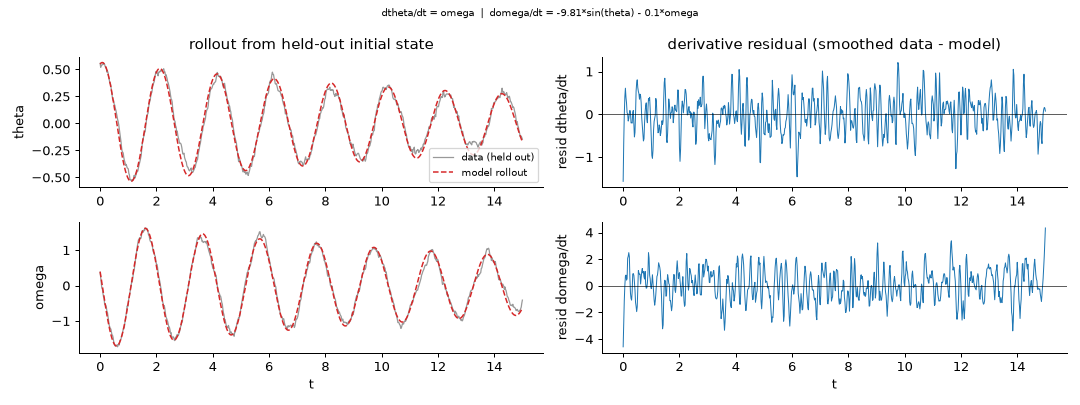

full report: runs/nb3_pendulum_n0.05red_dt1_s0/report.html


### michaelis_menten_n0.02mult_dt1_s0

**agent's model**

<IPython.core.display.Math object>

**ground truth**

<IPython.core.display.Math object>

**research trail:** intuit → diagnose → fit_skeleton → fit_skeleton → plot_data → fit_skeleton → weak_sindy → compare_models → submit

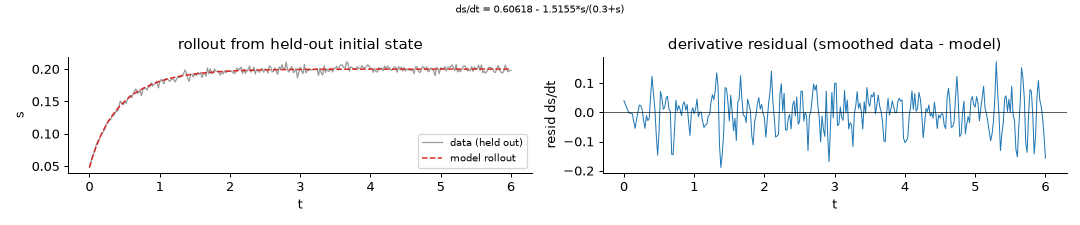

full report: runs/nb3_michaelis_menten_n0.02mult_dt1_s0/report.html


### sir_n0.05_dt1_s0

**agent's model**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

**ground truth**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**research trail:** diagnose → weak_sindy → fit_skeleton → submit

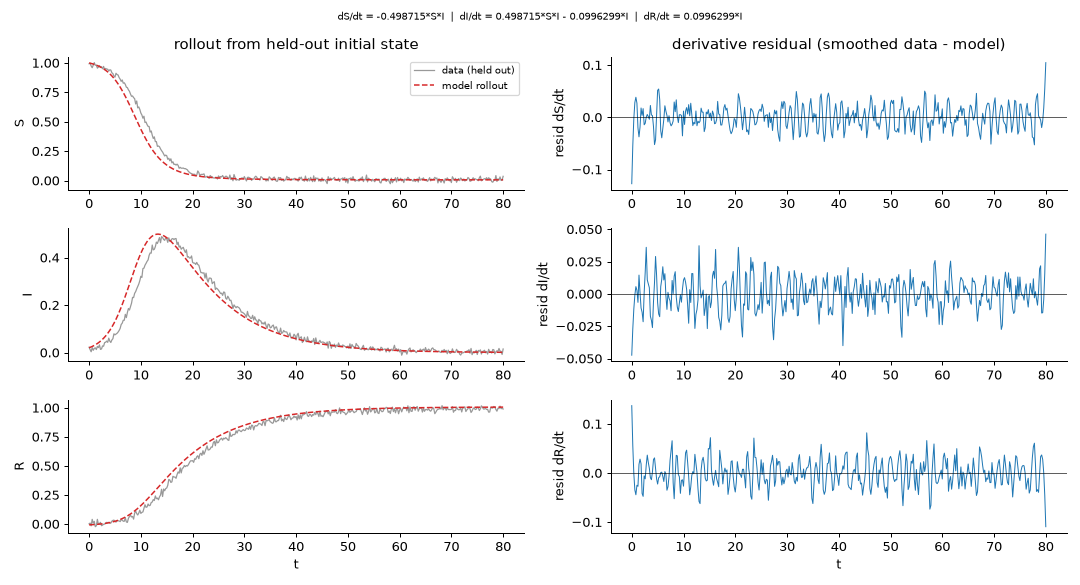

full report: runs/nb3_sir_n0.05_dt1_s0/report.html


In [5]:
for r in results:
    display(Markdown(f"### {r['dataset']}"))
    show_eqs(r["submitted"]["rhs"], "agent's model"); show_eqs(r["hidden_eval"]["truth"], "ground truth")
    display(Markdown("**research trail:** " + " → ".join(ev["name"] for ev in json.load(open(os.path.join(r["out_dir"], "transcript.json"))) if ev["type"] == "tool")))
    display(Image(os.path.join(r["out_dir"], "fig_model.png")))
    print("full report:", r.get("report"))

## 3.3 Baseline comparison

In [6]:
rows = []
for d, r in zip(targets, results):
    m_, d_ = load(d)
    rows.append({"dataset": os.path.basename(d), "SINDy": round(evaluate(d, tb.run_sindy(m_, d_))["score"], 2),
                 "agent": round(r["hidden_eval"]["score"], 2), "agent symbolic match": r.get("judge", {}).get("equivalent")})
pd.DataFrame(rows)

,dataset,SINDy,agent,agent symbolic match
0,pendulum_n0.05red_dt1_s0,0.77,6.44,True
1,michaelis_menten_n0.02mult_dt1_s0,1.47,2.31,True
2,sir_n0.05_dt1_s0,-0.79,2.90,True
